In [58]:
import pandas as pd
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import pickle
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

optimized_x_reg = np.load('optimized_x_reg.npy')
optimized_x_clf = np.load('optimized_x_clf.npy')
y_reg = np.load('y_reg.npy')
classification_y = np.load('classification_y.npy')
le = pickle.load(open('label_encoder.pkl', 'rb'))


Machine Learning Techniques (Supervised):

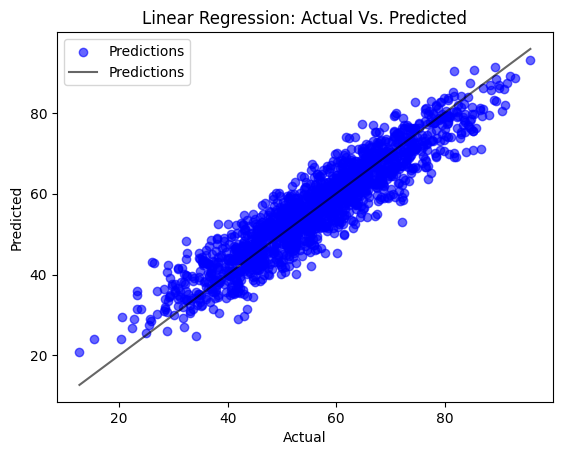

In [44]:

#Linear Regression
linear_Reg = LinearRegression()
x_train, x_test, y_train, y_test = train_test_split(optimized_x_reg, y_reg, test_size = 0.2, random_state=10)
linear_Model = linear_Reg.fit(x_train, y_train)
y_pred_linear = linear_Model.predict(x_test)

plt.scatter(y_test, y_pred_linear, color='blue', alpha=0.6, label='Predictions')

min_val = min(y_test.min(), y_pred_linear.min())
max_val = max(y_test.max(), y_pred_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', alpha=0.6, label='Predictions')
plt.title('Linear Regression: Actual Vs. Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.show()


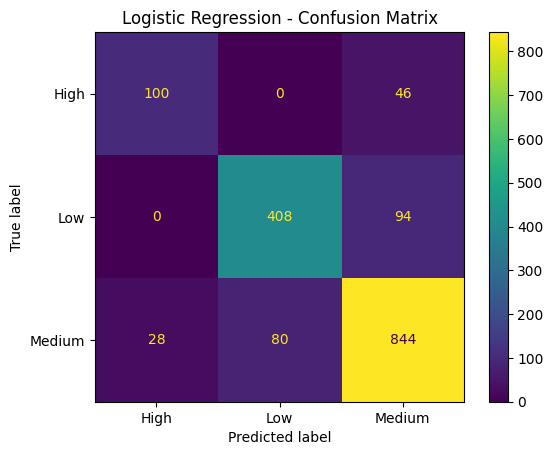

In [45]:
#Logistic Regression
class_x_train, class_x_test, class_y_train, class_y_test = train_test_split(optimized_x_clf, classification_y, test_size=0.2, random_state=10)
log_Reg = LogisticRegression(max_iter=5000)
log_Model = log_Reg.fit(class_x_train, class_y_train)
y_pred_log = log_Reg.predict(class_x_test)

ConfusionMatrixDisplay.from_estimator(log_Model, class_x_test, class_y_test, display_labels=le.classes_)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


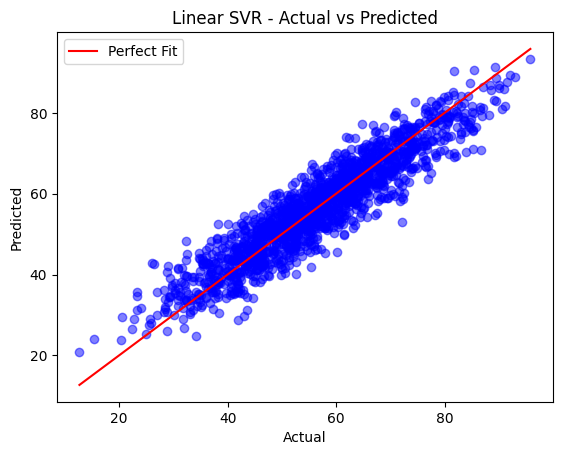

In [46]:

#Support Vector Machines (SVM)
svm_model = SVR(kernel='linear', epsilon=0.5)
svm_model.fit(x_train, y_train)
y_pred_svm = svm_model.predict(x_test)

plt.scatter(y_test, y_pred_svm, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect Fit')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title("Linear SVR - Actual vs Predicted")
plt.legend()
plt.show()

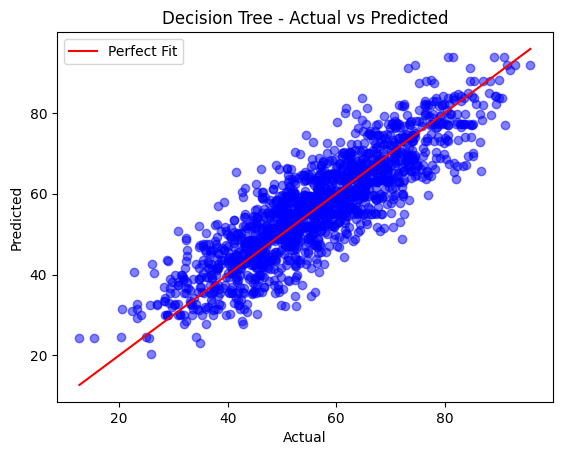

In [47]:
#Decision Trees
#tiffany
dt_model = DecisionTreeRegressor(max_depth=10, random_state=10, min_samples_split=3)
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)

plt.scatter(y_test, y_pred_dt, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect Fit')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title("Decision Tree - Actual vs Predicted")
plt.legend()
plt.show()

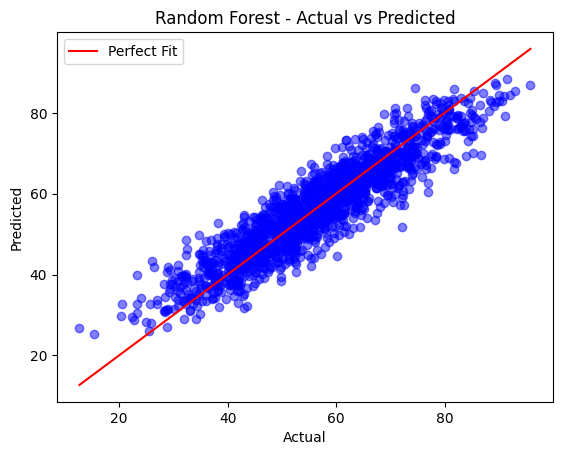

In [48]:
#Random Forests
#tiffany
rf_model = RandomForestRegressor(n_estimators=200, random_state=10)
rf_model.fit(x_train, y_train)
y_pred_rt = rf_model.predict(x_test)

plt.scatter(y_test, y_pred_rt, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect Fit')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title("Random Forest - Actual vs Predicted")
plt.legend()
plt.show()

Optimal K value (Elbow Method): 20


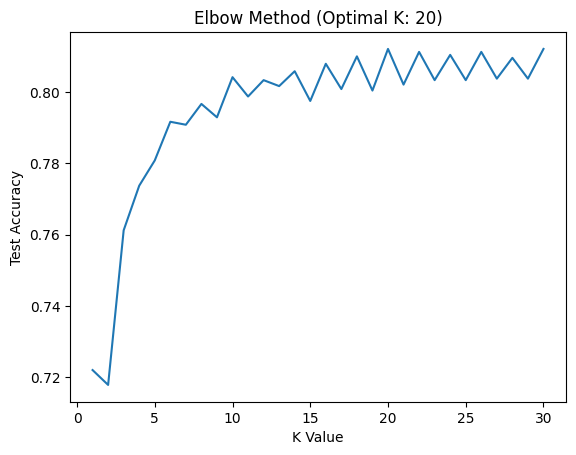

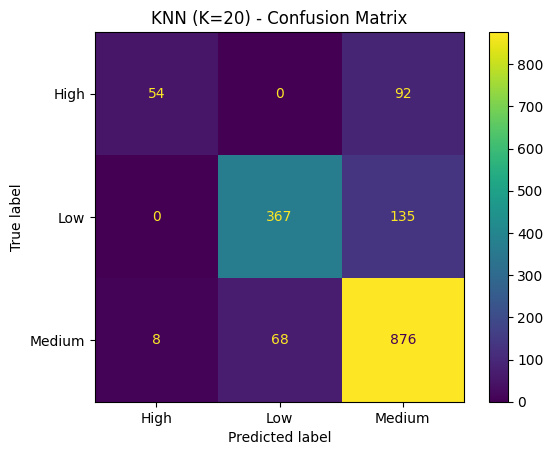

In [56]:
#k-Nearest Neighbors (k-NN)
def elbow_method(x, y, k_range):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
    test_scores=[]
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(x_train, y_train)
        test_scores.append(accuracy_score(y_test, knn.predict(x_test)))
        
    optimal_k = k_range[np.argmax(test_scores)]
    print(f"Optimal K value (Elbow Method): {optimal_k}")
    
    plt.plot(k_range, test_scores)
    plt.xlabel('K Value')
    plt.ylabel('Test Accuracy')
    plt.title(f'Elbow Method (Optimal K: {optimal_k})')
    plt.show()

elbow_method(optimized_x_clf, classification_y, range(1, 31))
knn = KNeighborsClassifier(n_neighbors=20, metric='euclidean')
knn.fit(class_x_train, class_y_train)
y_pred_knn = knn.predict(class_x_test)

ConfusionMatrixDisplay.from_estimator(knn, class_x_test, class_y_test, display_labels=le.classes_)
plt.title("KNN (K=20) - Confusion Matrix")
plt.show()

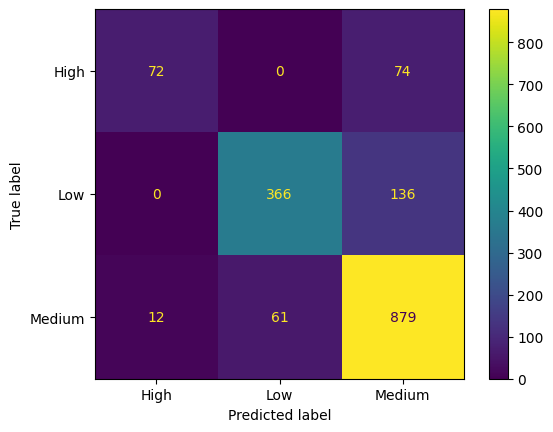

In [59]:
#Naive Bayes
gnb = GaussianNB()
gnb.fit(class_x_train, class_y_train)
y_pred_gnb = gnb.predict(class_x_test)
ConfusionMatrixDisplay.from_estimator(gnb, class_x_test, class_y_test, display_labels=le.classes_)

In [51]:
#Machine Learning Techniques (Unsupervised):


In [52]:
#k-Means Clustering
#tiffany 


In [53]:
#Hierarchical Clustering


In [54]:
#Prinicpal Component Analysis (PCA)


In [55]:
#Deep Learning:
#both of us? 
